# Conditional Probability

Let $A,B\in\mathcal F$ be events such that $P(B)>0$. The **conditional probability** of $A$ given $B$ is defined by

$$
P(A\mid B)=\frac{P(A\cap B)}{P(B)}.
$$

Intuitively, after learning that the event $B$ has occurred, the sample space is reduced from $\Omega$ to $B$, and probabilities are rescaled accordingly.

Rearranging the definition yields

$$
P(A\cap B)=P(A\mid B)P(B),
$$

which is often called the **multiplication rule**.

More generally, for events $A_1,\ldots,A_n$ satisfying

$$
P(A_1\cap\cdots\cap A_k)>0,
\qquad k=1,\ldots,n-1,
$$

we have

$$
P(A_1\cap\cdots\cap A_n)
=
P(A_1)
P(A_2\mid A_1)
P(A_3\mid A_1\cap A_2)
\cdots
P(A_n\mid A_1\cap\cdots\cap A_{n-1}).
$$

# Partitions of the Sample Space

A collection of events

$$
\{B_n\}_{n=1}^{N}
\quad
\text{or}
\quad
\{B_n\}_{n=1}^{\infty}
$$

is called a **partition** of the sample space $\Omega$ if

$$
B_i\cap B_j=\varnothing,
\qquad i\neq j,
$$

and

$$
\bigcup_{n} B_n=\Omega.
$$

# Law of Total Probability

Let $\{B_n\}$ be a partition of $\Omega$ such that $P(B_n)>0$ for all $n$.

Then for every event $A\in\mathcal F$,

$$
P(A)
=
\sum_n P(A\mid B_n)P(B_n).
$$

For a finite partition $\{B_1,\ldots,B_m\}$, this becomes

$$
P(A)
=
P(A\mid B_1)P(B_1)
+\cdots+
P(A\mid B_m)P(B_m).
$$

## Example: Exam Questions

Maria is worried about the exam in Probability and would like to maximize her chances of receiving an easy question.

There are $30$ students waiting in a line to enter the classroom. On the teacher's desk there are $30$ tickets, one question written on each ticket. Among these tickets, $10$ contain easy questions and $20$ contain difficult questions.

The students enter the classroom one by one. Each student randomly chooses one ticket, takes it with them, and sits down. Thus, after a student chooses a ticket, that ticket is no longer available for the next students.

Maria can choose any position in the line.

**Which position should Maria choose?** Should she be the first student in the line? The last one? Or perhaps somewhere in the middle?

Theoretical probability: 0.3333333333333333
Empirical probability for first student: 0.32
Empirical probability for last student: 0.325


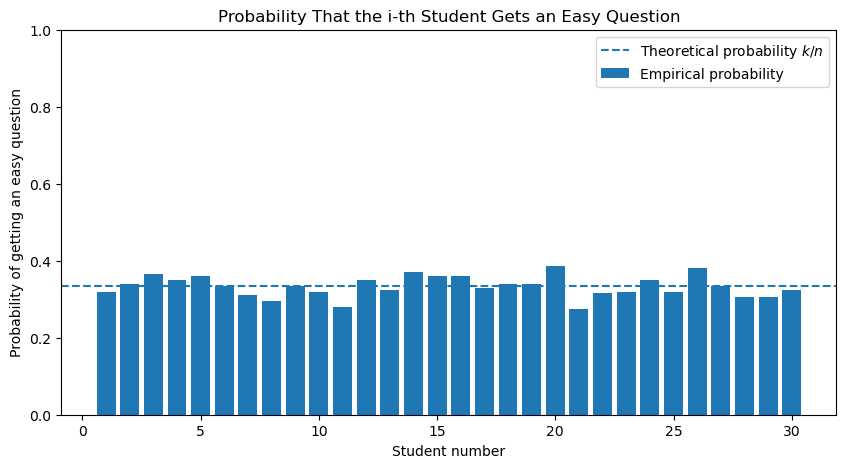

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Parameters
n = 30      # number of questions and students
k = 10      # number of easy questions
N = 200  # number of simulated exams

# 1 = easy question, 0 = difficult question
questions = np.array([1]*k + [0]*(n-k))

# results[j, i] = 1 if in simulation j the i-th student got an easy question
results = np.zeros((N, n), dtype=int)

for j in range(N):
    shuffled_questions = np.random.permutation(questions)
    results[j] = shuffled_questions

empirical_probs = results.mean(axis=0)
theoretical_prob = k/n

print("Theoretical probability:", theoretical_prob)
print("Empirical probability for first student:", empirical_probs[0])
print("Empirical probability for last student:", empirical_probs[-1])

plt.figure(figsize=(10, 5))

plt.bar(np.arange(1, n+1), empirical_probs, label="Empirical probability")
plt.axhline(theoretical_prob, linestyle="--", label=r"Theoretical probability $k/n$")

plt.xlabel("Student number")
plt.ylabel("Probability of getting an easy question")
plt.title("Probability That the i-th Student Gets an Easy Question")
plt.ylim(0, 1)
plt.legend()
plt.show()

## Example: The Drunk Passenger Problem

On January 1st, a flight from Moscow to Saint Petersburg with exactly $100$ passengers and exactly $100$ seats is preparing for boarding. Each passenger has an assigned seat, and all passengers arrive on time.

The first passenger to enter the plane has been celebrating New Year's Eve all night and is still somewhat drunk. As a result, instead of sitting in his assigned seat, he chooses one of the $100$ seats uniformly at random.

After that, the remaining passengers board one by one. Each passenger sits in their assigned seat if it is free. If their assigned seat is already occupied, they decide to avoid any arguments and simply choose one of the remaining free seats uniformly at random.

**Question:** What is the probability that the last passenger to board the plane ends up sitting in their assigned seat?

Empirical probability: 0.524
Theoretical probability: 0.5


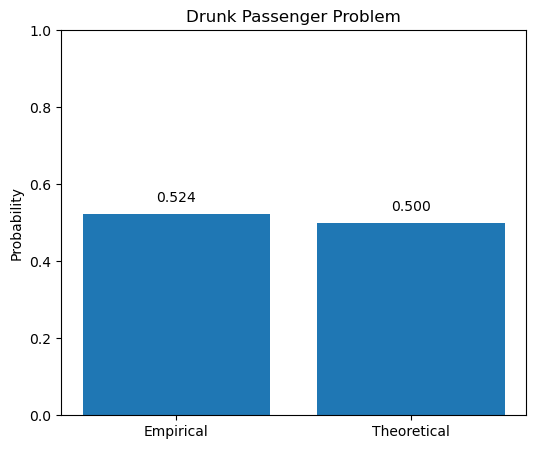

In [19]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 100
N = 500

successes = 0

for _ in range(N):
    occupied = np.zeros(n, dtype=bool)

    # Passenger 0 is drunk and chooses a random seat
    first_seat = np.random.randint(n)
    occupied[first_seat] = True

    # Passengers 1, 2, ..., n-2 enter
    for passenger in range(1, n-1):
        if not occupied[passenger]:
            occupied[passenger] = True
        else:
            free_seats = np.where(~occupied)[0]
            chosen_seat = np.random.choice(free_seats)
            occupied[chosen_seat] = True

    # Last passenger enters
    if not occupied[n-1]:
        successes += 1

empirical_probability = successes / N
theoretical_probability = 1/2

print("Empirical probability:", empirical_probability)
print("Theoretical probability:", theoretical_probability)

plt.figure(figsize=(6, 5))
plt.bar(
    ["Empirical", "Theoretical"],
    [empirical_probability, theoretical_probability]
)

plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Drunk Passenger Problem")

for i, v in enumerate([empirical_probability, theoretical_probability]):
    plt.text(i, v + 0.03, f"{v:.3f}", ha="center")

plt.show()

# Bayes' Formula

Suppose $\{B_n\}$ is a partition of $\Omega$ satisfying $P(B_n)>0$ for all $n$, and let $A\in\mathcal F$ be an event with $P(A)>0$.

Then for every $n$,

$$
P(B_n\mid A)
=
\frac{P(A\mid B_n)P(B_n)}
{\sum_k P(A\mid B_k)P(B_k)}.
$$

This identity is known as **Bayes' formula**.

- $P(B_n)$ is called the **prior probability**,

- $P(A\mid B_n)$ is called the **likelihood**,

- $P(B_n\mid A)$ is called the **posterior probability**.

Bayes' formula describes how probabilities should be updated when new information becomes available.

## Example: Medical Testing

A patient goes to see a doctor. The doctor performs a medical test with **99\% reliability**. This means that:

- $99\%$ of sick people test positive;
- $99\%$ of healthy people test negative.

The doctor also knows that only $0.1\%$ of the population is affected by the disease.

A patient takes the test and receives a **positive result**.

**Question:** What is the probability that the patient is actually sick?

Theoretical P(positive): 0.010980000000000009
Theoretical P(sick | positive): 0.09016393442622944

Empirical P(positive): 0.01073
Empirical P(sick | positive): 0.09226467847157502


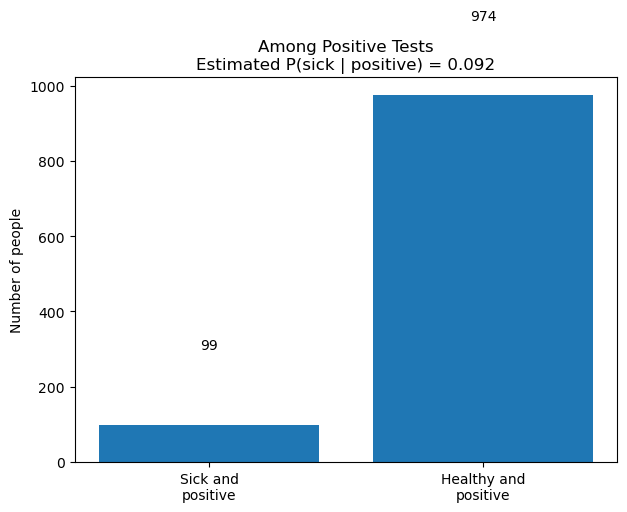

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Parameters
N = 100_000

p_sick = 0.001
p_positive_given_sick = 0.99
p_negative_given_healthy = 0.99
p_positive_given_healthy = 1 - p_negative_given_healthy

# Theoretical probabilities
p_positive = (
    p_positive_given_sick * p_sick
    +
    p_positive_given_healthy * (1 - p_sick)
)

p_sick_given_positive = (
    p_positive_given_sick * p_sick
) / p_positive

print("Theoretical P(positive):", p_positive)
print("Theoretical P(sick | positive):", p_sick_given_positive)

# Simulation
sick = np.random.random(N) < p_sick

test_positive = np.zeros(N, dtype=bool)

test_positive[sick] = (
    np.random.random(sick.sum()) < p_positive_given_sick
)

test_positive[~sick] = (
    np.random.random((~sick).sum()) < p_positive_given_healthy
)

empirical_p_positive = test_positive.mean()
empirical_p_sick_given_positive = sick[test_positive].mean()

print()
print("Empirical P(positive):", empirical_p_positive)
print("Empirical P(sick | positive):", empirical_p_sick_given_positive)

# Plot
true_positives = np.sum(sick & test_positive)
false_positives = np.sum(~sick & test_positive)

plt.figure(figsize=(7, 5))

plt.bar(
    ["Sick and\npositive", "Healthy and\npositive"],
    [true_positives, false_positives]
)

plt.ylabel("Number of people")
plt.title(
    "Among Positive Tests\n"
    f"Estimated P(sick | positive) = {empirical_p_sick_given_positive:.3f}"
)

for i, v in enumerate([true_positives, false_positives]):
    plt.text(i, v + 200, str(v), ha="center")

plt.show()

## Example: The Monty Hall Problem

Suppose you're on a game show, and you're given the choice of three doors. Behind one door is a car; behind the others, goats.

You pick a door, say Door 1. The host, who knows what's behind the doors, opens another door, say Door 3, which contains a goat.

The host then asks:

> "Do you want to switch your choice and pick Door 2 instead?"

**Question:** Is it to your advantage to switch your choice?

<p align="center">
<img src="images/monty.png" width="500">
</p>

Stay: 0.33312
Switch: 0.66688


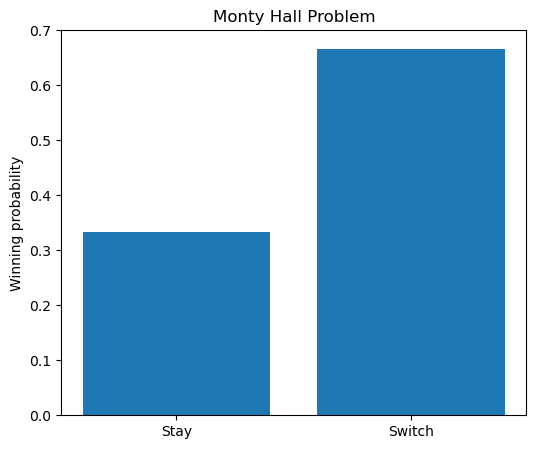

In [8]:
import numpy as np

N = 100_000

wins_switch = 0
wins_stay = 0

for _ in range(N):

    prize = np.random.randint(3)
    choice = np.random.randint(3)

    remaining = [
        d for d in range(3)
        if d != choice and d != prize
    ]

    host = np.random.choice(remaining)

    switch_to = [
        d for d in range(3)
        if d != choice and d != host
    ][0]

    wins_stay += (choice == prize)
    wins_switch += (switch_to == prize)

print("Stay:", wins_stay/N)
print("Switch:", wins_switch/N)

plt.figure(figsize=(6,5))

plt.bar(
    ["Stay", "Switch"],
    [wins_stay/N, wins_switch/N]
)

plt.ylabel("Winning probability")
plt.title("Monty Hall Problem")
plt.show()

# Conditional Probability in Large Language Models

Large language models such as ChatGPT are built around conditional probabilities.

When generating text, the model repeatedly estimates probabilities of the form

$$
P(\text{next word}\mid \text{previous words}).
$$

For example, after reading

> "The capital of France is"

the model assigns a very high probability to the word

> "Paris"

and a very small probability to words such as

> "banana".

At every step, the model chooses the next word based on these conditional probabilities.

Although modern AI systems use extremely sophisticated neural networks, conditional probability remains one of the fundamental mathematical ideas behind them.

In this sense, the formulas studied in this lecture are part of the mathematical foundation of modern artificial intelligence.

# Naive Bayes Classifier

One of the simplest machine learning algorithms is the **Naive Bayes classifier**.

Suppose that an object belongs to one of several classes

$$
C_1,C_2,\ldots,C_k.
$$

After observing some features

$$
X=(X_1,\ldots,X_n),
$$

Bayes' formula gives

$$
P(C_i\mid X)
=
\frac{P(X\mid C_i)P(C_i)}
     {P(X)}.
$$

The classifier predicts the class with the largest posterior probability.

The difficulty is that computing

$$
P(X\mid C_i)
$$

can be very complicated.

Naive Bayes assumes that the features are conditionally independent given the class:

$$
P(X_1,\ldots,X_n\mid C_i)
=
\prod_{j=1}^n P(X_j\mid C_i).
$$

Although this assumption is usually false, the resulting classifier often performs surprisingly well.